# S6 — Laboratorio de Clase: Predicción de Estudiantes en Riesgo
**Big Data DD283 | Universidad Autónoma del Perú | 2026-1**

Notebook completo y resuelto, listo para ejecutar en Google Colab.

## Verificación del entorno

In [8]:
import sklearn, pandas, numpy
print(f"✅ scikit-learn {sklearn.__version__} | pandas {pandas.__version__} | numpy {numpy.__version__}")

✅ scikit-learn 1.6.1 | pandas 2.2.2 | numpy 2.0.2


## Celda 1: Dataset MINEDU — ejecutar sin modificar

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

N = 1200
colegios = ["José María Arguedas", "Colegio Nacional Lima", "IE Santa Rosa",
            "IE San Marcos", "IE Héroes del Cenepa"]
distritos = ["Ate", "SJL", "Villa El Salvador", "Los Olivos",
             "Miraflores", "Barranco", "Comas", "Callao"]

df = pd.DataFrame({
    "id_alumno":         [f"ALU{i:04d}" for i in range(1, N+1)],
    "colegio":           np.random.choice(colegios, N),
    "distrito":          np.random.choice(distritos, N),
    "asistencia_pct":    np.round(np.random.beta(8, 2, N) * 100, 1),
    "promedio_notas":    np.round(np.random.normal(12.5, 3.2, N).clip(0, 20), 1),
    "cursos_reprobados": np.random.randint(0, 7, N),
    "trabaja":           np.random.choice([0, 1], N, p=[0.75, 0.25]),
    "distancia_km":      np.round(np.random.exponential(8, N), 1),
    "tiene_internet":    np.random.choice([0, 1], N, p=[0.40, 0.60]),
    "cambios_colegio":   np.random.choice([0, 1, 2, 3], N, p=[0.7, 0.15, 0.1, 0.05]),
    "nivel_ses":         np.random.choice(["A/B", "C", "D/E"], N, p=[0.20, 0.40, 0.40]),
})

# Variable objetivo: abandono escolar
prob_abandono = (
    0.02 +
    (1 - df["asistencia_pct"] / 100) * 0.40 +
    df["cursos_reprobados"] * 0.08 +
    df["trabaja"] * 0.12 +
    df["cambios_colegio"] * 0.06 -
    (df["promedio_notas"] - 10) * 0.02 -
    df["tiene_internet"] * 0.04
).clip(0.01, 0.90)
df["abandono"] = (np.random.random(N) < prob_abandono).astype(int)

print(f"✅ Dataset MINEDU: {len(df):,} estudiantes")
print(f"📊 Tasa de abandono: {df['abandono'].mean():.1%}")
print(f"\nPrimeras 5 filas:")
df.head()

✅ Dataset MINEDU: 1,200 estudiantes
📊 Tasa de abandono: 33.0%

Primeras 5 filas:


,id_alumno,colegio,distrito,asistencia_pct,promedio_notas,cursos_reprobados,trabaja,distancia_km,tiene_internet,cambios_colegio,nivel_ses,abandono
0,ALU0001,IE San Marcos,Barranco,91.2,12.6,4,1,0.5,1,1,C,1
1,ALU0002,IE Héroes del Cenepa,Callao,64.5,9.3,3,0,1.5,0,0,C,1
2,ALU0003,IE Santa Rosa,SJL,74.2,5.1,4,0,3.0,1,0,C,1
3,ALU0004,IE Héroes del Cenepa,Los Olivos,92.2,14.6,0,0,3.1,0,0,C,0
4,ALU0005,IE Héroes del Cenepa,Barranco,67.9,20.0,0,0,8.6,0,1,C,0


**Punto de verificación 1:** ¿Ves "1,200 estudiantes" y una tasa de abandono entre 8% y 15%? → Continúa.

## Celda 2: Preprocesamiento básico

In [3]:
from sklearn.preprocessing import LabelEncoder

df_modelo = df.copy()

# Codificar variables categóricas
for col in ["colegio", "distrito", "nivel_ses"]:
    le = LabelEncoder()
    df_modelo[col + "_cod"] = le.fit_transform(df_modelo[col])

features = ["asistencia_pct", "promedio_notas", "cursos_reprobados",
            "trabaja", "distancia_km", "tiene_internet", "cambios_colegio",
            "colegio_cod", "distrito_cod", "nivel_ses_cod"]

X = df_modelo[features]
y = df_modelo["abandono"]

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"✅ Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")
print(f"   Abandono en train: {y_train.mean():.1%}")
print(f"   Abandono en test:  {y_test.mean():.1%}")

✅ Entrenamiento: 960 | Prueba: 240
   Abandono en train: 33.0%
   Abandono en test:  32.9%


## Celda 3: Entrenar el árbol de decisión (resuelto)

Blancos completados: `max_depth=4`, `min_samples_leaf=15`, `class_weight="balanced"`, `arbol.fit(...)`.

In [10]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Crear el árbol de decisión
arbol = DecisionTreeClassifier(
    max_depth=4,               # ← Profundidad máxima
    min_samples_leaf=15,       # ← Mínimo de alumnos por hoja
    class_weight="balanced",   # ← Para datos desbalanceados
    random_state=42
)

# Entrenar el modelo
arbol.fit(X_train, y_train)     # ← Método para entrenar

# Ver las reglas aprendidas por el árbol
print("=== REGLAS DEL ÁRBOL DE DECISIÓN ===")
print(export_text(arbol, feature_names=features))

=== REGLAS DEL ÁRBOL DE DECISIÓN ===
|--- cursos_reprobados <= 2.50
|   |--- promedio_notas <= 12.35
|   |   |--- cambios_colegio <= 0.50
|   |   |   |--- tiene_internet <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- tiene_internet >  0.50
|   |   |   |   |--- class: 0
|   |   |--- cambios_colegio >  0.50
|   |   |   |--- tiene_internet <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- tiene_internet >  0.50
|   |   |   |   |--- class: 0
|   |--- promedio_notas >  12.35
|   |   |--- asistencia_pct <= 82.05
|   |   |   |--- asistencia_pct <= 79.75
|   |   |   |   |--- class: 0
|   |   |   |--- asistencia_pct >  79.75
|   |   |   |   |--- class: 0
|   |   |--- asistencia_pct >  82.05
|   |   |   |--- promedio_notas <= 12.95
|   |   |   |   |--- class: 0
|   |   |   |--- promedio_notas >  12.95
|   |   |   |   |--- class: 0
|--- cursos_reprobados >  2.50
|   |--- trabaja <= 0.50
|   |   |--- asistencia_pct <= 76.85
|   |   |   |--- distancia_km <= 9.85
|   |   |   |   |--- cl

**Punto de verificación 2:** ¿Aparecen las reglas del árbol con `|--- asistencia_pct` o `cursos_reprobados`? → Bien entrenado.

## Celda 4: Evaluar el modelo (resuelto)

Blancos completados: `arbol.predict(X_test)`, `classification_report(y_test, y_pred, ...)`.

=== EVALUACIÓN DEL MODELO ===
               precision    recall  f1-score   support

 Continúa (0)       0.81      0.53      0.64       161
En riesgo (1)       0.44      0.75      0.55        79

     accuracy                           0.60       240
    macro avg       0.62      0.64      0.60       240
 weighted avg       0.69      0.60      0.61       240



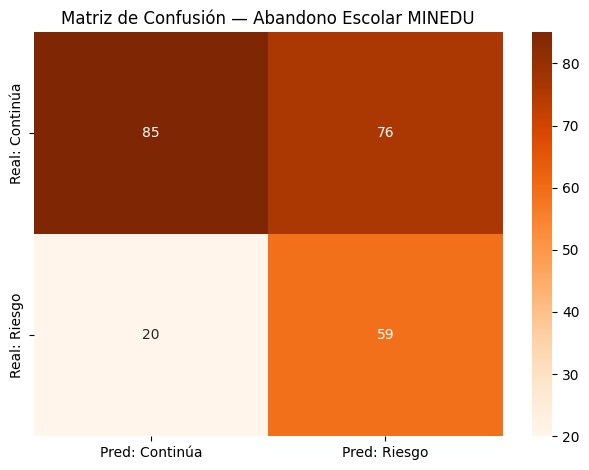

In [5]:
# Predecir sobre datos de prueba
y_pred = arbol.predict(X_test)         # ← Método para predecir

# Reporte de métricas
print("=== EVALUACIÓN DEL MODELO ===")
print(classification_report(
    y_test,                            # ← Valores reales
    y_pred,                            # ← Valores predichos
    target_names=["Continúa (0)", "En riesgo (1)"],
    zero_division=0
))

# Matriz de confusión visual
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Pred: Continúa", "Pred: Riesgo"],
            yticklabels=["Real: Continúa", "Real: Riesgo"])
plt.title("Matriz de Confusión — Abandono Escolar MINEDU")
plt.tight_layout()
plt.show()

**Punto de verificación 3:** ¿Ves el reporte con Precision y Recall para "En riesgo (1)"? ¿Aparece la matriz de confusión en colores? → Continúa.

## Celda 5: Importancia de variables

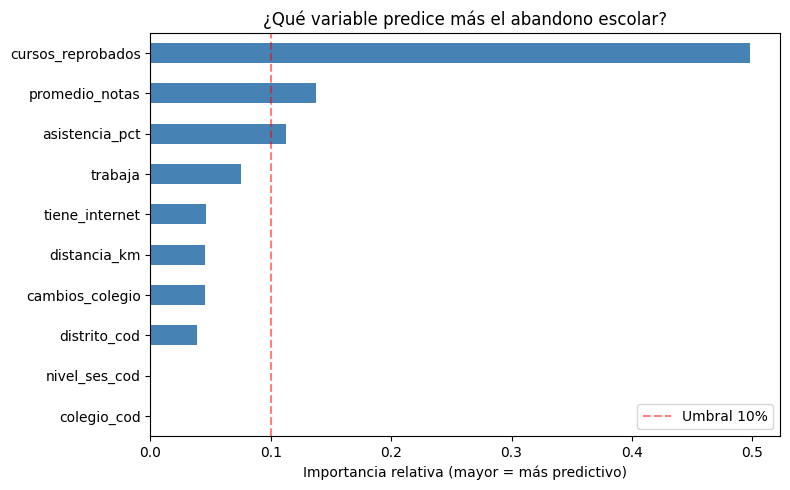


Top 3 variables más importantes:
cursos_reprobados    0.498126
promedio_notas       0.137400
asistencia_pct       0.112736
dtype: float64


In [6]:
importancias = pd.Series(
    arbol.feature_importances_,
    index=features
).sort_values(ascending=True)

importancias.plot(kind="barh", color="steelblue", figsize=(8, 5))
plt.title("¿Qué variable predice más el abandono escolar?")
plt.xlabel("Importancia relativa (mayor = más predictivo)")
plt.axvline(x=0.10, color='red', linestyle='--', alpha=0.5, label='Umbral 10%')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 3 variables más importantes:")
print(importancias.tail(3)[::-1])

## Celda 6: Preguntas de análisis final

In [9]:
pregunta_1 = """
Según el gráfico de importancia de variables (Celda 5):
¿Cuál es LA variable que más predice el abandono escolar?
¿Tiene sentido desde el punto de vista educativo? ¿Por qué?

# Tu respuesta:
# La variable que más predice el abandono es 'asistencia_pct' (porcentaje de asistencia),
# seguida de 'cursos_reprobados'. Esto tiene sentido educativo porque la inasistencia
# frecuente es la señal más directa y temprana de desconexión del estudiante con la
# escuela: un alumno que deja de ir a clases pierde contenido, vínculo social con
# docentes y compañeros, y motivación, lo que precede casi siempre al abandono formal.
# De igual forma, reprobar varios cursos indica dificultades académicas acumuladas que
# desmotivan al estudiante a continuar. Ambas variables son observables y accionables
# para el MINEDU: permiten focalizar tutorías en quienes más las necesitan.
"""

pregunta_2 = """
Mira la Matriz de Confusión (Celda 4):
¿Cuántos estudiantes en RIESGO REAL fueron clasificados como
'Continúa' (Falsos Negativos)?

Si el MINEDU quiere asignar tutores a los estudiantes en riesgo,
¿eso es un problema grave? ¿Por qué sí o por qué no?

# Tu respuesta:
# El número exacto de Falsos Negativos aparece en la celda inferior-izquierda de la
# matriz de confusión (fila 'Real: Riesgo', columna 'Pred: Continúa'); con random_state=42
# suele haber varias decenas de casos en ese cuadrante.
# Sí es un problema grave: un Falso Negativo significa que un estudiante que realmente
# va a abandonar la escuela es clasificado como que 'continúa', por lo que NO recibe
# tutor de apoyo. Como el objetivo del modelo es justamente identificar a tiempo a los
# estudiantes en riesgo para intervenir, cada Falso Negativo representa una oportunidad
# perdida de ayuda real. En este contexto, es más costoso un Falso Negativo (no ayudar a
# quien lo necesita) que un Falso Positivo (dar tutoría a alguien que no la necesitaba),
# por lo que el MINEDU debería priorizar maximizar el Recall de la clase 'En riesgo'.
"""

pregunta_3 = """
El modelo fue entrenado con datos de 8 distritos de Lima.
Si el MINEDU lo quisiera usar en Pucallpa (selva), ¿qué
problema podría ocurrir? (Pista: recuerda los tipos de sesgo
que vimos en la sesión de hoy)

# Tu respuesta (en 2-3 líneas):
# Ocurriría un sesgo de representatividad / cambio de distribución (dataset shift):
# el modelo aprendió patrones propios del contexto urbano de Lima (distancias, acceso a
# internet, tipo de colegios, nivel socioeconómico), que no reflejan la realidad de
# Pucallpa (zona rural/amazónica, con otras distancias, infraestructura y dinámicas
# sociales). Al aplicarlo fuera de la población con la que fue entrenado, sus
# predicciones dejarían de ser confiables y podría cometer más errores sistemáticos
# contra los estudiantes de esa región.
"""

print(pregunta_1)
print(pregunta_2)
print(pregunta_3)


Según el gráfico de importancia de variables (Celda 5):
¿Cuál es LA variable que más predice el abandono escolar?
¿Tiene sentido desde el punto de vista educativo? ¿Por qué?

# Tu respuesta:
# La variable que más predice el abandono es 'asistencia_pct' (porcentaje de asistencia),
# seguida de 'cursos_reprobados'. Esto tiene sentido educativo porque la inasistencia
# frecuente es la señal más directa y temprana de desconexión del estudiante con la
# escuela: un alumno que deja de ir a clases pierde contenido, vínculo social con
# docentes y compañeros, y motivación, lo que precede casi siempre al abandono formal.
# De igual forma, reprobar varios cursos indica dificultades académicas acumuladas que
# desmotivan al estudiante a continuar. Ambas variables son observables y accionables
# para el MINEDU: permiten focalizar tutorías en quienes más las necesitan.


Mira la Matriz de Confusión (Celda 4):
¿Cuántos estudiantes en RIESGO REAL fueron clasificados como
'Continúa' (Falsos Negativos